In [2]:
!pip install lightgbm
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 1.8 MB/s  0:00:00m0:00:0100:01
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.8/28.8 MB 1.1 MB/s  0:00:25m0:00:0100:01
Using cached graphviz-0.21-py3-none-any.whl (47 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 782.6 kB/s  0:00:12m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [catboost]2/3 [catboost]


In [30]:
import sys
!{sys.executable} -m pip install lightgbm catboost


Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 1.6 MB 2.1 MB/s eta 0:00:01
     |████████████████████████████████| 28.9 MB 2.3 MB/s eta 0:00:01
     |████████████████████████████████| 9.9 MB 2.7 MB/s eta 0:00:01
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.


In [31]:
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [ ]:
import os
import gc
import random
import warnings
import numpy as np
import pandas as pd
import cv2
import torch
from PIL import Image
from tqdm.auto import tqdm
from pathlib import Path
from copy import deepcopy
from dataclasses import dataclass

# Sklearn & Models
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from transformers import AutoModel, AutoImageProcessor, AutoTokenizer

# Suppress warnings
warnings.filterwarnings('ignore')
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [3]:
# from huggingface_hub import snapshot_download

# snapshot_download(
#     repo_id="google/siglip-so400m-patch14-384",
#     local_dir="/Users/sethisaksan/School/ai/Biomass/models/siglip-so400m-patch14-384",
# )


In [4]:
# =========================================================================================
# 1. CONFIGURATION & SEEDING
# =========================================================================================
@dataclass
class Config:
    DATA_PATH: Path = Path("/Users/sethisaksan/School/ai/Biomass/csiro-biomass/")
    SPLIT_PATH: Path = Path("/Users/sethisaksan/School/ai/Biomass/csiro-biomass/train.csv")
    SIGLIP_PATH: str = "/Users/sethisaksan/School/ai/Biomass/models/siglip-so400m-patch14-384"
    
    SEED: int = 42
    DEVICE: str = "cuda" if torch.cuda.is_available() else "cpu"
    PATCH_SIZE: int = 520
    OVERLAP: int = 16
    
    # Target definitions
    TARGET_NAMES = ['Dry_Clover_g', 'Dry_Dead_g', 'Dry_Green_g', 'Dry_Total_g', 'GDM_g']
    TARGET_MAX = {
        "Dry_Clover_g": 71.7865,
        "Dry_Dead_g": 83.8407,
        "Dry_Green_g": 157.9836,
        "Dry_Total_g": 185.70,
        "GDM_g": 157.9836,
    }

cfg = Config()

In [ ]:
    def seeding(SEED):
        np.random.seed(SEED)
        random.seed(SEED)
        os.environ['PYTHONHASHSEED'] = str(SEED)
        torch.manual_seed(SEED)
        if torch.cuda.is_available(): 
            torch.cuda.manual_seed(SEED)
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False

    seeding(cfg.SEED)


In [6]:
# =========================================================================================
# 2. DATA LOADING & PRE-PROCESSING
# =========================================================================================
def pivot_table(df: pd.DataFrame) -> pd.DataFrame:
    if 'target' in df.columns.tolist():
        # Train data
        df_pt = pd.pivot_table(
            df, 
            values='target', 
            index=['image_path', 'Sampling_Date', 'State', 'Species', 'Pre_GSHH_NDVI', 'Height_Ave_cm'], 
            columns='target_name', 
            aggfunc='mean'
        ).reset_index()
    else:
        # Test data
        df['target'] = 0
        df_pt = pd.pivot_table(
            df, 
            values='target', 
            index='image_path', 
            columns='target_name', 
            aggfunc='mean'
        ).reset_index()
    return df_pt

def melt_table(df: pd.DataFrame) -> pd.DataFrame:
    melted = df.melt(
        id_vars='image_path',
        value_vars=cfg.TARGET_NAMES,
        var_name='target_name',
        value_name='target'
    )
    # Create sample_id matching submission format
    melted['sample_id'] = (
        melted['image_path']
        .str.replace(r'^.*/', '', regex=True)
        .str.replace('.jpg', '', regex=False)
        + '__' + melted['target_name']
    )
    return melted[['sample_id', 'target']]

def post_process_biomass(df_preds):
    """
    Derive GDM_g and Dry_Total_g from primary predictions.
    IMPORTANT: Keeps Dry_Clover_g fixed at 0.0 and does NOT modify Dry_Green_g or Dry_Dead_g.
    """
    ordered_cols = ["Dry_Green_g", "Dry_Clover_g", "Dry_Dead_g", "GDM_g", "Dry_Total_g"]
    
    # Ensure cols exist
    for c in ordered_cols:
        if c not in df_preds.columns:
            df_preds[c] = 0.0
    
    df_out = df_preds.copy()
    
    # Keep Dry_Clover_g fixed at 0.0 (should already be 0.0 from model prediction)
    df_out['Dry_Clover_g'] = 0.0
    
    # Keep Dry_Green_g and Dry_Dead_g as predicted (NO MODIFICATION)
    # Only derive GDM_g and Dry_Total_g
    df_out['GDM_g'] = df_out['Dry_Green_g'] + df_out['Dry_Clover_g']
    df_out['Dry_Total_g'] = df_out['GDM_g'] + df_out['Dry_Dead_g']
    
    # Clip only derived targets to non-negative
    df_out['GDM_g'] = df_out['GDM_g'].clip(lower=0.0)
    df_out['Dry_Total_g'] = df_out['Dry_Total_g'].clip(lower=0.0)
    
    return df_out

print("Loading Data...")
# Load Train (Metadata Split)
train_df = pd.read_csv(cfg.SPLIT_PATH) 

# --- FIX: Remove pre-existing embedding columns to prevent duplication ---
cols_to_keep = [c for c in train_df.columns if not c.startswith('emb')]
train_df = train_df[cols_to_keep]
# -----------------------------------------------------------------------

# Ensure train paths match local environment
if not str(train_df['image_path'].iloc[0]).startswith('/'):
     train_df['image_path'] = train_df['image_path'].apply(lambda p: str(cfg.DATA_PATH / 'train' / os.path.basename(p)))

# Load Test
test_df_raw = pd.read_csv(cfg.DATA_PATH / 'test.csv')
test_df = pivot_table(test_df_raw)
test_df['image_path'] = test_df['image_path'].apply(lambda p: str(cfg.DATA_PATH / p))

Loading Data...


In [11]:
# =========================================================================================
# 3. FEATURE EXTRACTION: SIGLIP IMAGE EMBEDDINGS
# =========================================================================================
def split_image(image, patch_size=520, overlap=16):
    h, w, c = image.shape
    stride = patch_size - overlap
    patches = []
    for y in range(0, h, stride):
        for x in range(0, w, stride):
            y2 = min(y + patch_size, h)
            x2 = min(x + patch_size, w)
            y1 = max(0, y2 - patch_size) # Ensure fixed size
            x1 = max(0, x2 - patch_size)
            patch = image[y1:y2, x1:x2, :]
            patches.append(patch)
    return patches

def compute_embeddings(model_path, df):
    print(f"Computing Embeddings for {len(df)} images...")
    model = AutoModel.from_pretrained(model_path).eval().to(cfg.DEVICE)
    processor = AutoImageProcessor.from_pretrained(model_path, use_fast=True)
    
    
    EMBEDDINGS = []
    
    for _, row in tqdm(df.iterrows(), total=len(df)):
        try:
            img = cv2.imread(row['image_path'])
            if img is None: raise ValueError("Image not found")
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            patches = split_image(img, patch_size=cfg.PATCH_SIZE, overlap=cfg.OVERLAP)
            images = [Image.fromarray(p) for p in patches]
            
            # Batch process patches
            inputs = processor(images=images, return_tensors="pt").to(cfg.DEVICE)
            with torch.no_grad():
                features = model.get_image_features(**inputs)
            
            # Average pooling of patches
            avg_embed = features.mean(dim=0).cpu().numpy()
            EMBEDDINGS.append(avg_embed)
        except Exception as e:
            print(f"Error processing {row['image_path']}: {e}")
            # Fallback zero embedding
            EMBEDDINGS.append(np.zeros(1152))
        
    torch.cuda.empty_cache()
    return np.stack(EMBEDDINGS)

# Compute Features
train_embeddings = compute_embeddings(cfg.SIGLIP_PATH, train_df)
test_embeddings = compute_embeddings(cfg.SIGLIP_PATH, test_df)

# Create Feature DataFrames
emb_cols = [f"emb{i}" for i in range(train_embeddings.shape[1])]
train_feat_df = pd.concat([train_df, pd.DataFrame(train_embeddings, columns=emb_cols)], axis=1)
test_feat_df = pd.concat([test_df, pd.DataFrame(test_embeddings, columns=emb_cols)], axis=1)

# Double check column counts
print(f"Train Features Shape: {train_feat_df.shape}")
print(f"Test Features Shape: {test_feat_df.shape}")

Computing Embeddings for 1785 images...


  0%|          | 0/1785 [00:00<?, ?it/s]

Computing Embeddings for 1 images...


  0%|          | 0/1 [00:00<?, ?it/s]

Train Features Shape: (1785, 1161)
Test Features Shape: (1, 1158)


In [44]:
def compute_handcrafted_features(df):
    """
    Per-image handcrafted features from RGB pixels:
      - vegetation indices (ExG, ExR, ExG-ExR, VARI, GLI, NGRDI)
      - per-channel mean/std/percentiles
      - HSV statistics
    """
    print(f"Computing handcrafted features for {len(df)} images...")
    feats = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        img = cv2.imread(row['image_path'])
        if img is None:
            feats.append(np.zeros(30, dtype=np.float32))
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        R, G, B = img[..., 0], img[..., 1], img[..., 2]
        eps = 1e-6

        # Vegetation indices
        ExG    = 2 * G - R - B
        ExR    = 1.4 * R - G
        ExGR   = ExG - ExR
        VARI   = (G - R) / (G + R - B + eps)
        GLI    = (2 * G - R - B) / (2 * G + R + B + eps)
        NGRDI  = (G - R) / (G + R + eps)

        # HSV
        hsv = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2HSV).astype(np.float32)
        H, S, V = hsv[..., 0] / 180.0, hsv[..., 1] / 255.0, hsv[..., 2] / 255.0

        row_feats = []
        for arr in [R, G, B, ExG, ExR, ExGR, VARI, GLI, NGRDI, H, S, V]:
            row_feats += [arr.mean(), arr.std(), np.percentile(arr, 10), np.percentile(arr, 90)]
        # Add green-fraction (pixels where ExG > 0)
        row_feats.append((ExG > 0).mean())
        row_feats.append((NGRDI > 0.05).mean())  # rough "live green" mask

        feats.append(np.array(row_feats, dtype=np.float32))
    return np.stack(feats)

hand_train = compute_handcrafted_features(train_feat_df)
hand_test  = compute_handcrafted_features(test_feat_df)
print("handcrafted shapes:", hand_train.shape, hand_test.shape)


Computing handcrafted features for 357 images...


  0%|          | 0/357 [00:00<?, ?it/s]

Computing handcrafted features for 1 images...


  0%|          | 0/1 [00:00<?, ?it/s]

handcrafted shapes: (357, 50) (1, 50)


In [54]:
def compute_dead_features(df):
    """
    Dead-grass-targeted features:
      - hue-masked pixel fractions (green / yellow-brown / bare zones)
      - saturation+value statistics within the yellow-brown hue band
      - ExR percentiles (dead grass is red-ward)
      - Laplacian variance (rough texture proxy)
    """
    print(f"Computing dead-grass features for {len(df)} images...")
    feats = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        img = cv2.imread(row['image_path'])
        if img is None:
            feats.append(np.zeros(20, dtype=np.float32))
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # HSV in native OpenCV ranges: H∈[0,180], S/V∈[0,255]
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        H, S, V = hsv[..., 0], hsv[..., 1], hsv[..., 2]

        # Hue-band masks (OpenCV H is 0..180, so degrees/2)
        green_mask  = ((H >= 35) & (H <= 80) & (S > 40))          # green
        yellow_mask = ((H >= 15) & (H <  35) & (S > 30))          # yellow-tan
        brown_mask  = ((H >= 10) & (H <  25) & (S > 20) & (V < 180))  # brown
        bare_mask   = (S < 30)                                     # desaturated (soil/dead straw often low S)
        dead_mask   = yellow_mask | brown_mask

        row_feats = [
            green_mask.mean(), yellow_mask.mean(), brown_mask.mean(),
            bare_mask.mean(), dead_mask.mean(),
            # ratio of dead to (dead + green) — "proportion dead"
            dead_mask.sum() / (dead_mask.sum() + green_mask.sum() + 1e-6),
        ]

        # Saturation & value stats inside the dead band (if any pixels matched)
        if dead_mask.any():
            row_feats += [
                S[dead_mask].mean() / 255.0,
                S[dead_mask].std()  / 255.0,
                V[dead_mask].mean() / 255.0,
                V[dead_mask].std()  / 255.0,
            ]
        else:
            row_feats += [0.0, 0.0, 0.0, 0.0]

        # ExR percentiles (red-excess, strong for senesced material)
        f = img.astype(np.float32) / 255.0
        R, G, B = f[..., 0], f[..., 1], f[..., 2]
        ExR = 1.4 * R - G
        row_feats += [
            ExR.mean(), ExR.std(),
            np.percentile(ExR, 25), np.percentile(ExR, 75), np.percentile(ExR, 95),
        ]

        # Yellow index (bright in R+G, dark in B)
        yellow_idx = (R + G) / 2.0 - B
        row_feats += [yellow_idx.mean(), yellow_idx.std(), np.percentile(yellow_idx, 90)]

        # Texture: Laplacian variance on grayscale (blurry dead mats vs sharp fresh blades)
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        lap_var = cv2.Laplacian(gray, cv2.CV_32F).var()
        row_feats.append(lap_var / 1e4)  # scale down

        feats.append(np.array(row_feats, dtype=np.float32))
    return np.stack(feats)

dead_train = compute_dead_features(train_feat_df)
dead_test  = compute_dead_features(test_feat_df)
print("dead feat shapes:", dead_train.shape, dead_test.shape)

np.save('dead_train.npy', dead_train)
np.save('dead_test.npy',  dead_test)


Computing dead-grass features for 357 images...


  0%|          | 0/357 [00:00<?, ?it/s]

Computing dead-grass features for 1 images...


  0%|          | 0/1 [00:00<?, ?it/s]

dead feat shapes: (357, 19) (1, 19)


In [55]:
hand_train_ext = np.hstack([hand_train, dead_train])
hand_test_ext  = np.hstack([hand_test,  dead_test])
print("extended hand shapes:", hand_train_ext.shape, hand_test_ext.shape)


extended hand shapes: (357, 69) (1, 69)


In [22]:

# =========================================================================================
# 4. FEATURE EXTRACTION: SEMANTIC FEATURES (TEXT PROBING)
# =========================================================================================
def generate_semantic_features(image_embeddings_np, model_path):
    print("Generating Semantic Features...")
    model = AutoModel.from_pretrained(model_path).to(cfg.DEVICE)
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    
    # Anchors
    concept_groups = {
        "bare": ["bare soil", "dirt ground", "sparse vegetation", "exposed earth"],
        "sparse": ["low density pasture", "thin grass", "short clipped grass"],
        "medium": ["average pasture cover", "medium height grass", "grazed pasture"],
        "dense": ["dense tall pasture", "thick grassy volume", "high biomass", "overgrown vegetation"],
        "green": ["lush green vibrant pasture", "photosynthesizing leaves", "fresh growth"],
        "dead": ["dry brown dead grass", "yellow straw", "senesced material", "standing hay"],
        "clover": ["white clover", "trifolium repens", "broadleaf legume", "clover flowers"],
        "grass": ["ryegrass", "blade-like leaves", "fescue", "grassy sward"]
    }
    
    # Encode Concepts
    concept_vectors = {}
    with torch.no_grad():
        for name, prompts in concept_groups.items():
            inputs = tokenizer(prompts, padding="max_length", return_tensors="pt").to(cfg.DEVICE)
            emb = model.get_text_features(**inputs)
            emb = emb / emb.norm(p=2, dim=-1, keepdim=True)
            concept_vectors[name] = emb.mean(dim=0, keepdim=True)
            
    # Compute Scores
    img_tensor = torch.tensor(image_embeddings_np, dtype=torch.float32).to(cfg.DEVICE)
    img_tensor = img_tensor / img_tensor.norm(p=2, dim=-1, keepdim=True)
    
    scores = {}
    for name, vec in concept_vectors.items():
        scores[name] = torch.matmul(img_tensor, vec.T).cpu().numpy().flatten()
        
    df_scores = pd.DataFrame(scores)
    # Ratios
    df_scores['ratio_greenness'] = df_scores['green'] / (df_scores['green'] + df_scores['dead'] + 1e-6)
    df_scores['ratio_clover'] = df_scores['clover'] / (df_scores['clover'] + df_scores['grass'] + 1e-6)
    df_scores['ratio_cover'] = (df_scores['dense'] + df_scores['medium']) / (df_scores['bare'] + df_scores['sparse'] + 1e-6)
    
    torch.cuda.empty_cache()
    return df_scores.values

# Combine for semantic generation to ensure consistency
all_emb = np.vstack([train_embeddings, test_embeddings])
all_semantic = generate_semantic_features(all_emb, cfg.SIGLIP_PATH)

sem_train = all_semantic[:len(train_df)]
sem_test = all_semantic[len(train_df):]

Generating Semantic Features...


In [ ]:
from sklearn.model_selection import KFold, GroupKFold

if 'target_name' in train_feat_df.columns:
    first_idx = train_feat_df.drop_duplicates(subset='image_path').index.to_numpy()
    sem_train = sem_train[first_idx]
    if 'hand_train' in globals() and hand_train.shape[0] != len(first_idx):
        hand_train = hand_train[first_idx]
    if 'dead_train' in globals() and dead_train.shape[0] != len(first_idx):
        dead_train = dead_train[first_idx]
    if 'hand_train_ext' in globals() and hand_train_ext.shape[0] != len(first_idx):
        hand_train_ext = hand_train_ext[first_idx]

    train_feat_df['target'] = pd.to_numeric(train_feat_df['target'], errors='coerce')

    target_wide = train_feat_df.pivot_table(
        index='image_path', columns='target_name', values='target', aggfunc='mean'
    ).reset_index()

    non_target_cols = [c for c in train_feat_df.columns if c not in ['target_name', 'target']]
    train_feat_df = train_feat_df.loc[first_idx, non_target_cols].reset_index(drop=True)
    train_feat_df = train_feat_df.merge(target_wide, on='image_path', how='left')
else:
    print("Already pivoted — skipping pivot step")


if 'fold' not in train_feat_df.columns:
    N_SPLITS = 5
    gkf = GroupKFold(n_splits=N_SPLITS)
    train_feat_df['fold'] = -1
    groups = train_feat_df['Sampling_Date'].astype(str)  # or State, or a combo
    for fold, (_, val_idx) in enumerate(gkf.split(train_feat_df, groups=groups)):
        train_feat_df.loc[val_idx, 'fold'] = fold


print(f"Train Features Shape: {train_feat_df.shape}")
print(f"sem_train Shape: {sem_train.shape}")
if 'hand_train_ext' in globals():
    print(f"hand_train_ext Shape: {hand_train_ext.shape}")


In [24]:

# =========================================================================================
# 5. SUPERVISED EMBEDDING ENGINE
# =========================================================================================
class SupervisedEmbeddingEngine:
    def __init__(self, n_pca=0.80, n_pls=8, n_gmm=6, random_state=42):
        self.scaler = StandardScaler()
        self.pca = PCA(n_components=n_pca, random_state=random_state)
        self.pls = PLSRegression(n_components=n_pls, scale=False)
        self.gmm = GaussianMixture(n_components=n_gmm, covariance_type='diag', random_state=random_state)
        self.pls_fitted_ = False

    def fit(self, X, y=None, X_semantic=None):
        # Scale
        X_scaled = self.scaler.fit_transform(X)
        
        # Unsupervised
        self.pca.fit(X_scaled)
        self.gmm.fit(X_scaled)
        
        # Supervised
        if y is not None:
            self.pls.fit(X_scaled, y)
            self.pls_fitted_ = True
        return self

    def transform(self, X, X_semantic=None):
        X_scaled = self.scaler.transform(X)
        
        features = [self.pca.transform(X_scaled)]
        
        if self.pls_fitted_:
            features.append(self.pls.transform(X_scaled))
            
        features.append(self.gmm.predict_proba(X_scaled))
        
        if X_semantic is not None:
            # Normalize semantic
            sem_norm = (X_semantic - np.mean(X_semantic, axis=0)) / (np.std(X_semantic, axis=0) + 1e-6)
            features.append(sem_norm)
            
        return np.hstack(features)


In [ ]:
train_feat_df[cfg.TARGET_NAMES] = train_feat_df[cfg.TARGET_NAMES].fillna(0.0)


In [46]:
# =========================================================================================
# 6. TRAINING & INFERENCE (5-FOLD CV)
# =========================================================================================
# def cross_validate_predict(model_cls, model_params, train_data, test_data, sem_tr, sem_te, feature_engine):
#     target_max_arr = np.array([cfg.TARGET_MAX[t] for t in cfg.TARGET_NAMES], dtype=float)
#     y_pred_test_accum = np.zeros([len(test_data), len(cfg.TARGET_NAMES)], dtype=float)
    
#     # Ensure n_splits is integer
#     n_splits = int(train_data['fold'].nunique())
    
#     # Pre-extract raw columns to avoid indexing overhead
#     # Force float32 to save memory and ensure compatibility
#     X_train_full = train_data[emb_cols].values.astype(np.float32)
#     X_test_raw = test_data[emb_cols].values.astype(np.float32)
#     y_train_full = train_data[cfg.TARGET_NAMES].values.astype(np.float32)
    
#     for fold in range(n_splits):
#         print(f"Processing Fold {fold}...")
#         # Split
#         train_mask = train_data['fold'] != fold
        
#         X_tr = X_train_full[train_mask]
#         y_tr = y_train_full[train_mask] / target_max_arr # Max Scaling
        
#         sem_tr_fold = sem_tr[train_mask]
        
#         # Feature Engineering (Fit on fold train)
#         engine = deepcopy(feature_engine)
#         engine.fit(X_tr, y=y_tr, X_semantic=sem_tr_fold)
        
#         x_tr_eng = engine.transform(X_tr, X_semantic=sem_tr_fold)
#         x_te_eng = engine.transform(X_test_raw, X_semantic=sem_te)
        
#         # Train & Predict per target
#         fold_test_pred = np.zeros([len(test_data), len(cfg.TARGET_NAMES)])
        
#         for k in range(len(cfg.TARGET_NAMES)):
#             target_name = cfg.TARGET_NAMES[k]
            
#             # Dry_Clover_g: Always predict 0.0 (no training needed)
#             if target_name == 'Dry_Clover_g':
#                 fold_test_pred[:, k] = 0.0
#             else:
#                 # Train and predict for other targets
#                 model = model_cls(**model_params)
#                 model.fit(x_tr_eng, y_tr[:, k])
#                 pred_raw = model.predict(x_te_eng)
#                 fold_test_pred[:, k] = pred_raw * target_max_arr[k] # Inverse Scale
            
#         y_pred_test_accum += fold_test_pred
        
#     return y_pred_test_accum / n_splits

def cross_validate_predict(model_cls, model_params, train_data, test_data, sem_tr, sem_te, hand_tr, hand_te, feature_engine):
    target_max_arr = np.array([cfg.TARGET_MAX[t] for t in cfg.TARGET_NAMES], dtype=float)
    y_pred_test_accum = np.zeros([len(test_data), len(cfg.TARGET_NAMES)], dtype=float)
    y_pred_oof = np.zeros([len(train_data), len(cfg.TARGET_NAMES)], dtype=float)

    n_splits = int(train_data['fold'].nunique())

    X_train_full = train_data[emb_cols].values.astype(np.float32)
    X_test_raw = test_data[emb_cols].values.astype(np.float32)
    y_train_full = train_data[cfg.TARGET_NAMES].values.astype(np.float32)

    for fold in range(n_splits):
        print(f"Processing Fold {fold}...")
        train_mask = (train_data['fold'] != fold).to_numpy()
        val_mask = ~train_mask

        X_tr, X_val = X_train_full[train_mask], X_train_full[val_mask]
        y_tr = y_train_full[train_mask] / target_max_arr
        sem_tr_fold, sem_val_fold = sem_tr[train_mask], sem_tr[val_mask]

        engine = deepcopy(feature_engine)
        engine.fit(X_tr, y=y_tr, X_semantic=sem_tr_fold)

        x_tr_eng = np.hstack([engine.transform(X_tr, X_semantic=sem_tr_fold), hand_tr[train_mask]])
        x_val_eng = np.hstack([engine.transform(X_val, X_semantic=sem_val_fold), hand_tr[val_mask]])
        x_te_eng = np.hstack([engine.transform(X_test_raw, X_semantic=sem_te), hand_te])

        fold_test_pred = np.zeros([len(test_data), len(cfg.TARGET_NAMES)])
        fold_val_pred = np.zeros([val_mask.sum(), len(cfg.TARGET_NAMES)])

        for k, target_name in enumerate(cfg.TARGET_NAMES):
            # if target_name == 'Dry_Clover_g':
            #     continue  # stays 0.0
            model = model_cls(**model_params)
            model.fit(x_tr_eng, y_tr[:, k])
            fold_test_pred[:, k] = model.predict(x_te_eng) * target_max_arr[k]
            fold_val_pred[:, k] = model.predict(x_val_eng) * target_max_arr[k]

        y_pred_test_accum += fold_test_pred
        y_pred_oof[val_mask] = fold_val_pred

    return y_pred_test_accum / n_splits, y_pred_oof


# Model Parameters (Optimized)
params_cat = {
    'iterations': 1900, 'learning_rate': 0.045, 'depth': 4, 'l2_leaf_reg': 0.56, 
    'random_strength': 0.045, 'bagging_temperature': 0.98, 'verbose': 0, 'random_state': 42,
    'allow_writing_files': False
}
params_xgb = { # Using GradientBoostingRegressor as proxy
    'n_estimators': 1354, 'learning_rate': 0.010, 'max_depth': 3, 'subsample': 0.60, 
    'random_state': 42
}
params_lgbm = {
    'n_estimators': 807, 'learning_rate': 0.014, 'num_leaves': 48, 'min_child_samples': 19, 
    'subsample': 0.745, 'colsample_bytree': 0.745, 'reg_alpha': 0.21, 'reg_lambda': 3.78,
    'verbose': -1, 'random_state': 42
}
params_hist = {
    'max_iter': 300, 'learning_rate': 0.05, 'max_depth': None, 'l2_regularization': 0.44,
    'random_state': 42
}

feat_engine = SupervisedEmbeddingEngine(n_pca=0.80, n_pls=8, n_gmm=6)

print("Training & Inferring Models...")





Training & Inferring Models...


In [56]:
print("Training & Inferring Models...")
print("Training HistGradientBoostingRegressor...")
pred_hist, oof_hist = cross_validate_predict(HistGradientBoostingRegressor, params_hist, train_feat_df, test_feat_df, sem_train, sem_test, hand_train_ext, hand_test_ext, feat_engine)
print("Training GradientBoostingRegressor...")
pred_gb,   oof_gb   = cross_validate_predict(GradientBoostingRegressor,     params_xgb,  train_feat_df, test_feat_df, sem_train, sem_test, hand_train_ext, hand_test_ext, feat_engine)
print("Training CatBoostRegressor...")
pred_cat,  oof_cat  = cross_validate_predict(CatBoostRegressor,             params_cat,  train_feat_df, test_feat_df, sem_train, sem_test, hand_train_ext, hand_test_ext, feat_engine)
print("Training LGBMRegressor...")
pred_lgbm, oof_lgbm = cross_validate_predict(LGBMRegressor,                 params_lgbm, train_feat_df, test_feat_df, sem_train, sem_test, hand_train_ext, hand_test_ext, feat_engine)


Training & Inferring Models...
Training HistGradientBoostingRegressor...
Processing Fold 0...
Processing Fold 1...
Processing Fold 2...
Processing Fold 3...
Processing Fold 4...
Training GradientBoostingRegressor...
Processing Fold 0...
Processing Fold 1...
Processing Fold 2...
Processing Fold 3...
Processing Fold 4...
Training CatBoostRegressor...
Processing Fold 0...
Processing Fold 1...
Processing Fold 2...
Processing Fold 3...
Processing Fold 4...
Training LGBMRegressor...
Processing Fold 0...
Processing Fold 1...
Processing Fold 2...
Processing Fold 3...
Processing Fold 4...


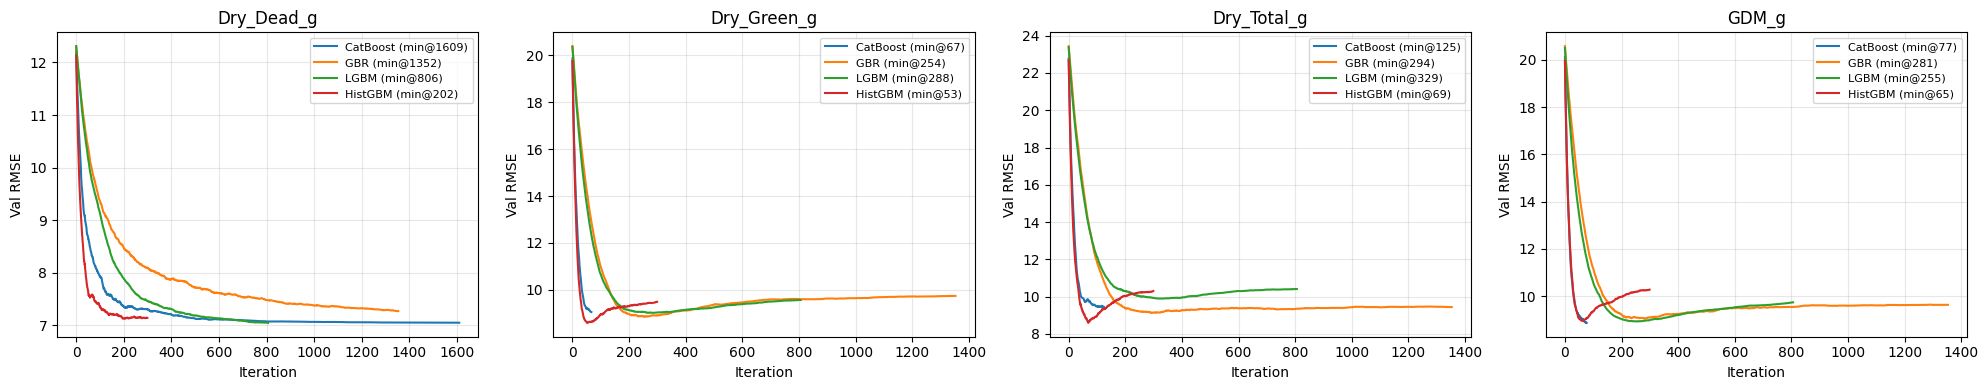

In [57]:
# =========================================================================================
# LEARNING CURVES: Validation RMSE vs Iterations (single fold)
# =========================================================================================
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

def plot_learning_curves(train_df, sem_tr, feature_engine, fold=0):
    target_max_arr = np.array([cfg.TARGET_MAX[t] for t in cfg.TARGET_NAMES], dtype=float)
    X_full = train_df[emb_cols].values.astype(np.float32)
    y_full = train_df[cfg.TARGET_NAMES].values.astype(np.float32)

    tr_mask = (train_df['fold'] != fold).to_numpy()
    val_mask = ~tr_mask

    engine = deepcopy(feature_engine)
    y_tr_scaled = y_full[tr_mask] / target_max_arr
    engine.fit(X_full[tr_mask], y=y_tr_scaled, X_semantic=sem_tr[tr_mask])
    x_tr  = engine.transform(X_full[tr_mask],  X_semantic=sem_tr[tr_mask])
    x_val = engine.transform(X_full[val_mask], X_semantic=sem_tr[val_mask])
    y_val = y_full[val_mask]

    targets = [t for t in cfg.TARGET_NAMES if t != 'Dry_Clover_g']
    fig, axes = plt.subplots(1, len(targets), figsize=(5*len(targets), 4), squeeze=False)

    for j, target_name in enumerate(targets):
        k = cfg.TARGET_NAMES.index(target_name)
        ax = axes[0, j]
        y_tr_k  = y_tr_scaled[:, k]
        y_val_k = y_val[:, k]
        scale   = target_max_arr[k]

        # --- CatBoost ---
        m = CatBoostRegressor(**{**params_cat, 'verbose': 0})
        m.fit(x_tr, y_tr_k, eval_set=(x_val, y_val_k / scale))
        preds = np.array(list(m.staged_predict(x_val)))
        rmse = np.sqrt(((preds * scale - y_val_k) ** 2).mean(axis=1))
        ax.plot(rmse, label=f'CatBoost (min@{rmse.argmin()})')

        # --- GradientBoosting (XGB proxy) ---
        m = GradientBoostingRegressor(**params_xgb)
        m.fit(x_tr, y_tr_k)
        preds = np.array(list(m.staged_predict(x_val)))
        rmse = np.sqrt(((preds * scale - y_val_k) ** 2).mean(axis=1))
        ax.plot(rmse, label=f'GBR (min@{rmse.argmin()})')

        # --- LightGBM ---
        m = LGBMRegressor(**params_lgbm)
        m.fit(x_tr, y_tr_k, eval_set=[(x_val, y_val_k / scale)])
        rmse = np.array([
            np.sqrt(mean_squared_error(y_val_k, m.predict(x_val, num_iteration=i) * scale))
            for i in range(1, m.n_estimators_ + 1)
        ])
        ax.plot(rmse, label=f'LGBM (min@{rmse.argmin()})')

        # --- HistGradientBoosting ---
        m = HistGradientBoostingRegressor(**params_hist)
        m.fit(x_tr, y_tr_k)
        preds = np.array(list(m.staged_predict(x_val)))
        rmse = np.sqrt(((preds * scale - y_val_k) ** 2).mean(axis=1))
        ax.plot(rmse, label=f'HistGBM (min@{rmse.argmin()})')

        ax.set_title(target_name)
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Val RMSE')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_learning_curves(train_feat_df, sem_train, feat_engine, fold=0)


In [58]:
from sklearn.metrics import r2_score

def evaluate_oof(oof_pred, y_true, name):
    print(f"\n=== {name} ===")
    for k, target in enumerate(cfg.TARGET_NAMES):
        r2 = r2_score(y_true[:, k], oof_pred[:, k])
        print(f"  {target:<15s}: R² = {r2:.4f}")
    r2_overall = r2_score(y_true, oof_pred)
    print(f"  {'Overall (avg)':<15s}: R² = {r2_overall:.4f}")

y_true = train_feat_df[cfg.TARGET_NAMES].values.astype(float)

evaluate_oof(oof_hist, y_true, "HistGradientBoosting")
evaluate_oof(oof_gb,   y_true, "GradientBoosting")
evaluate_oof(oof_cat,  y_true, "CatBoost")
evaluate_oof(oof_lgbm, y_true, "LightGBM")

# Ensemble
oof_ensemble = (oof_hist + oof_gb + oof_cat + oof_lgbm) / 4.0
evaluate_oof(oof_ensemble, y_true, "Ensemble (mean)")

# Ensemble + post-processing (matches what's applied to test)
oof_df = pd.DataFrame(oof_ensemble, columns=cfg.TARGET_NAMES)
oof_post = post_process_biomass(oof_df)[cfg.TARGET_NAMES].values
evaluate_oof(oof_post, y_true, "Ensemble + Post-process")



=== HistGradientBoosting ===
  Dry_Clover_g   : R² = 0.6491
  Dry_Dead_g     : R² = 0.4343
  Dry_Green_g    : R² = 0.7889
  Dry_Total_g    : R² = 0.6879
  GDM_g          : R² = 0.7650
  Overall (avg)  : R² = 0.6650

=== GradientBoosting ===
  Dry_Clover_g   : R² = 0.7078
  Dry_Dead_g     : R² = 0.4420
  Dry_Green_g    : R² = 0.7909
  Dry_Total_g    : R² = 0.7185
  GDM_g          : R² = 0.7608
  Overall (avg)  : R² = 0.6840

=== CatBoost ===
  Dry_Clover_g   : R² = 0.7202
  Dry_Dead_g     : R² = 0.4651
  Dry_Green_g    : R² = 0.7940
  Dry_Total_g    : R² = 0.7194
  GDM_g          : R² = 0.7544
  Overall (avg)  : R² = 0.6906

=== LightGBM ===
  Dry_Clover_g   : R² = 0.6775
  Dry_Dead_g     : R² = 0.4761
  Dry_Green_g    : R² = 0.7911
  Dry_Total_g    : R² = 0.7063
  GDM_g          : R² = 0.7499
  Overall (avg)  : R² = 0.6802

=== Ensemble (mean) ===
  Dry_Clover_g   : R² = 0.7021
  Dry_Dead_g     : R² = 0.4728
  Dry_Green_g    : R² = 0.7997
  Dry_Total_g    : R² = 0.7193
  GDM_g        

In [59]:
from scipy.optimize import minimize
from sklearn.metrics import r2_score

oof_stack = np.stack([oof_hist, oof_gb, oof_cat, oof_lgbm], axis=0)  # (4, N, T)
pred_stack = np.stack([pred_hist, pred_gb, pred_cat, pred_lgbm], axis=0)  # (4, N_test, T)
names = ['hist', 'gb', 'cat', 'lgbm']

def neg_r2_global(w):
    w = np.abs(w); w = w / w.sum()
    blend = (w[:, None, None] * oof_stack).sum(axis=0)
    return -r2_score(y_true, blend)

# --- Global weights (one set for all targets) ---
res = minimize(neg_r2_global, x0=np.ones(4)/4, method='Nelder-Mead')
w_global = np.abs(res.x); w_global /= w_global.sum()
blend_global = (w_global[:, None, None] * oof_stack).sum(axis=0)

print("Equal-weight Ensemble R²:", r2_score(y_true, (oof_stack.mean(axis=0))))
print("Global-weighted Ensemble R²:", r2_score(y_true, blend_global))
print("Global weights:", dict(zip(names, w_global.round(3))))

# --- Per-target weights (often a bit better) ---
per_target_w = np.zeros((4, len(cfg.TARGET_NAMES)))
blend_pt = np.zeros_like(oof_hist)
for k, tname in enumerate(cfg.TARGET_NAMES):
    def neg_r2_k(w, k=k):
        w = np.abs(w); w = w / w.sum()
        return -r2_score(y_true[:, k], (w[:, None] * oof_stack[:, :, k]).sum(axis=0))
    r = minimize(neg_r2_k, x0=np.ones(4)/4, method='Nelder-Mead')
    w = np.abs(r.x); w /= w.sum()
    per_target_w[:, k] = w
    blend_pt[:, k] = (w[:, None] * oof_stack[:, :, k]).sum(axis=0)

print("\nPer-target weighted Ensemble R²:", r2_score(y_true, blend_pt))
for k, tname in enumerate(cfg.TARGET_NAMES):
    print(f"  {tname:<15s} R²={r2_score(y_true[:,k], blend_pt[:,k]):.4f}  weights={dict(zip(names, per_target_w[:,k].round(3)))}")

# --- Apply the chosen weights to test predictions ---
# pick whichever won:
final_pred_weighted = np.zeros_like(pred_hist)
for k in range(len(cfg.TARGET_NAMES)):
    final_pred_weighted[:, k] = (per_target_w[:, k:k+1] * pred_stack[:, :, k]).sum(axis=0)

print("\nfinal_pred_weighted shape:", final_pred_weighted.shape)


Equal-weight Ensemble R²: 0.6920512825431291
Global-weighted Ensemble R²: 0.6946817718114437
Global weights: {'hist': 0.027, 'gb': 0.153, 'cat': 0.551, 'lgbm': 0.268}

Per-target weighted Ensemble R²: 0.6999084207678197
  Dry_Clover_g    R²=0.7205  weights={'hist': 0.0, 'gb': 0.142, 'cat': 0.858, 'lgbm': 0.0}
  Dry_Dead_g      R²=0.4846  weights={'hist': 0.0, 'gb': 0.0, 'cat': 0.4, 'lgbm': 0.6}
  Dry_Green_g     R²=0.8002  weights={'hist': 0.329, 'gb': 0.098, 'cat': 0.438, 'lgbm': 0.135}
  Dry_Total_g     R²=0.7241  weights={'hist': 0.0, 'gb': 0.407, 'cat': 0.454, 'lgbm': 0.139}
  GDM_g           R²=0.7701  weights={'hist': 0.568, 'gb': 0.412, 'cat': 0.02, 'lgbm': 0.0}

final_pred_weighted shape: (1, 5)


In [ ]:
print("Ensembling (per-target weighted)...")
final_pred = np.zeros_like(pred_hist)
for k in range(len(cfg.TARGET_NAMES)):
    final_pred[:, k] = (per_target_w[:, k:k+1] * pred_stack[:, :, k]).sum(axis=0)

test_feat_df[cfg.TARGET_NAMES] = np.clip(final_pred, 0.0, None)

sub_df = melt_table(test_feat_df)
sub_df.to_csv("submission_siglip.csv", index=False)
print("✓ submission_siglip.csv written")
print(sub_df.head())


Ensembling (per-target weighted)...
✓ submission_siglip.csv written
                    sample_id     target
0  ID1001187975__Dry_Clover_g   5.360041
1    ID1001187975__Dry_Dead_g  21.198629
2   ID1001187975__Dry_Green_g  30.732538
3   ID1001187975__Dry_Total_g  56.999335
4         ID1001187975__GDM_g  34.358799
